# Experiment: Choosing the Latent Dimension of a Variational Autoencoder

## Project scenario

A handwritten-digit exploration system needs a variational autoencoder that can:

- reconstruct recognizable digits;
- generate plausible images from $z\sim\mathcal{N}(0,I)$;
- produce meaningful, gradual interpolations; and
- maintain a compact latent representation.

Your task is to compare four candidate latent dimensions and recommend one:

$$
d_z\in\{2,8,16,64\}.
$$

The architecture, optimizer, training data, data order, number of epochs, and $\beta$ remain fixed. The notebook trains every candidate, calculates the same diagnostics, and saves the tables and figures used in the project report.

## Questions to consider before running the experiment

Record your predictions in the report before examining the results.

1. Which latent dimension do you expect to reconstruct images best?
2. Which latent dimension do you expect to generate the best samples from the prior?
3. Can a larger latent dimension contain inactive dimensions?
4. Does a compact latent dimension necessarily produce a better organized latent space?
5. What evidence would justify choosing a smaller model when a larger model has a slightly better reconstruction loss?

## 1. Environment and experiment configuration

Run the notebook from top to bottom. A GPU is recommended. MNIST is downloaded automatically on the first run.

In [1]:
from pathlib import Path
import json
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.decomposition import PCA
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

SEED = 42
LATENT_DIMENSIONS = [2, 8, 16, 64]
BETA = 1.0
EPOCHS = 8
BATCH_SIZE = 256
LEARNING_RATE = 1e-3
ACTIVE_KL_THRESHOLD = 0.01
NUM_WORKERS = 2
DATA_ROOT = Path("data")
OUTPUT_DIR = Path("outputs/latent_dimension_experiment")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__} | device={device}")
print(f"Latent dimensions: {LATENT_DIMENSIONS}")

PyTorch 2.14.0 | device=cpu
Latent dimensions: [2, 8, 16, 64]


In [2]:
def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything()

transform = transforms.ToTensor()
train_dataset = datasets.MNIST(DATA_ROOT, train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(DATA_ROOT, train=False, download=True, transform=transform)

loader_options = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": torch.cuda.is_available(),
}
train_loader = DataLoader(
    train_dataset, shuffle=True,
    generator=torch.Generator().manual_seed(SEED),
    **loader_options,
)
test_loader = DataLoader(test_dataset, shuffle=False, **loader_options)

sample_images, sample_labels = next(iter(test_loader))
print(f"Training examples: {len(train_dataset):,}")
print(f"Test examples: {len(test_dataset):,}")
print(f"Batch shape: {tuple(sample_images.shape)}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 15.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 447kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 5.10MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 1.67MB/s]


Training examples: 60,000
Test examples: 10,000
Batch shape: (256, 1, 28, 28)


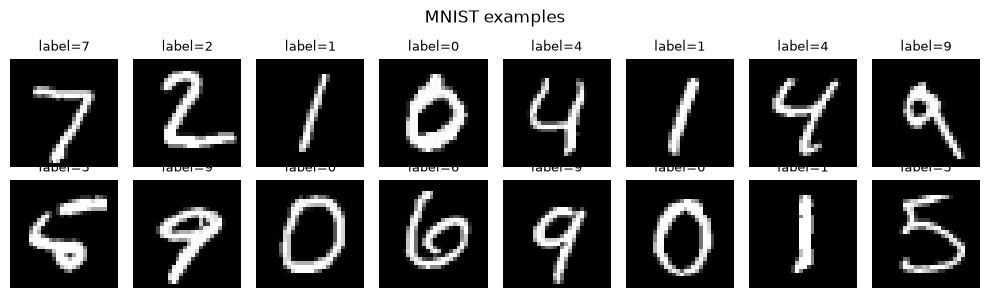

In [3]:
fig, axes = plt.subplots(2, 8, figsize=(10, 3))
for ax, image, label in zip(axes.flat, sample_images[:16], sample_labels[:16]):
    ax.imshow(image.squeeze(), cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"label={label.item()}", fontsize=9)
    ax.axis("off")
plt.suptitle("MNIST examples")
plt.tight_layout()
plt.show()

## 2. Variational autoencoder

The encoder returns the parameters of a diagonal Gaussian posterior:

$$
q_\phi(\mathbf z\mid\mathbf x)
=\mathcal N\left(\boldsymbol\mu_\phi(\mathbf x),
\operatorname{diag}(\boldsymbol\sigma_\phi^2(\mathbf x))\right).
$$

A latent sample is produced with

$$
\mathbf z=\boldsymbol\mu+\boldsymbol\sigma\odot\boldsymbol\epsilon,
\qquad \boldsymbol\epsilon\sim\mathcal N(0,I).
$$

The decoder returns logits for a Bernoulli pixel likelihood.

In [4]:
class ConvVAE(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.latent_dim = latent_dim
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),  # 28 -> 14
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1), # 14 -> 7
            nn.ReLU(inplace=True),
            nn.Flatten(),
        )
        self.mu_head = nn.Linear(64 * 7 * 7, latent_dim)
        self.logvar_head = nn.Linear(64 * 7 * 7, latent_dim)
        self.decoder_input = nn.Linear(latent_dim, 64 * 7 * 7)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1), # 7 -> 14
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),  # 14 -> 28
        )

    def encode(self, x):
        features = self.encoder(x)
        return self.mu_head(features), self.logvar_head(features)

    @staticmethod
    def reparameterize(mu, logvar):
        std = torch.exp(0.5 * logvar)
        epsilon = torch.randn_like(std)
        return mu + std * epsilon

    def decode(self, z):
        features = self.decoder_input(z).view(-1, 64, 7, 7)
        return self.decoder(features)

    def forward(self, x, sample=True):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar) if sample else mu
        logits = self.decode(z)
        return logits, mu, logvar

## 3. Objective and evaluation quantities

For every image, the negative evidence lower bound is

$$
\mathcal J_{\mathrm{VAE}}
=\mathcal L_{\mathrm{reconstruction}}
+\beta D_{\mathrm{KL}}\left(q_\phi(\mathbf z\mid\mathbf x)\parallel p(\mathbf z)\right).
$$

For a diagonal posterior and standard-normal prior, the contribution of latent dimension $j$ is

$$
D_{\mathrm{KL},j}
=-\frac{1}{2}\left(1+\log\sigma_j^2-\mu_j^2-\sigma_j^2\right).
$$

A dimension is counted as active when its average KL contribution is greater than `ACTIVE_KL_THRESHOLD`. This indicates that its posterior differs measurably from the prior.

In [5]:
def vae_terms(logits, x, mu, logvar, beta=BETA):
    reconstruction = F.binary_cross_entropy_with_logits(logits, x, reduction="sum")
    kl_per_dimension = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp())
    kl = kl_per_dimension.sum()
    batch_size = x.size(0)
    return {
        "loss": (reconstruction + beta * kl) / batch_size,
        "reconstruction": reconstruction / batch_size,
        "kl": kl / batch_size,
    }

def run_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train(training)
    totals = {"loss": 0.0, "reconstruction": 0.0, "kl": 0.0}
    examples = 0

    for x, _ in loader:
        x = x.to(device, non_blocking=True)
        if training:
            optimizer.zero_grad(set_to_none=True)
        with torch.set_grad_enabled(training):
            logits, mu, logvar = model(x, sample=True)
            terms = vae_terms(logits, x, mu, logvar)
            if training:
                terms["loss"].backward()
                optimizer.step()

        batch_size = x.size(0)
        for key in totals:
            totals[key] += terms[key].item() * batch_size
        examples += batch_size

    return {key: value / examples for key, value in totals.items()}

In [6]:
@torch.no_grad()
def collect_latent_statistics(model, loader, max_examples=None):
    model.eval()
    all_mu, all_logvar, all_labels = [], [], []
    collected = 0

    for x, labels in loader:
        x = x.to(device, non_blocking=True)
        mu, logvar = model.encode(x)
        all_mu.append(mu.cpu())
        all_logvar.append(logvar.cpu())
        all_labels.append(labels.cpu())
        collected += x.size(0)
        if max_examples is not None and collected >= max_examples:
            break

    mu = torch.cat(all_mu)
    logvar = torch.cat(all_logvar)
    labels = torch.cat(all_labels)
    if max_examples is not None:
        mu, logvar, labels = mu[:max_examples], logvar[:max_examples], labels[:max_examples]

    kl_per_example_and_dimension = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp())
    mean_kl_per_dimension = kl_per_example_and_dimension.mean(dim=0)
    active_mask = mean_kl_per_dimension > ACTIVE_KL_THRESHOLD

    return {
        "mu": mu,
        "logvar": logvar,
        "labels": labels,
        "mean_kl_per_dimension": mean_kl_per_dimension,
        "active_dimensions": int(active_mask.sum().item()),
        "active_fraction": float(active_mask.float().mean().item()),
    }

def count_parameters(model):
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)

## 4. Run the controlled experiment

Each candidate is trained for the same number of epochs. The reported reconstruction, KL, and negative-ELBO values are averages per image on the test set.

In [7]:
models = {}
histories = {}
latent_statistics = {}
summary_rows = []

for latent_dim in LATENT_DIMENSIONS:
    print(f"\n{'=' * 68}\nTraining VAE with latent_dim={latent_dim}\n{'=' * 68}")
    seed_everything(SEED)
    model = ConvVAE(latent_dim).to(device)
    experiment_train_loader = DataLoader(
        train_dataset, shuffle=True,
        generator=torch.Generator().manual_seed(SEED),
        **loader_options,
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    history = []
    started = time.time()

    for epoch in range(1, EPOCHS + 1):
        train_metrics = run_epoch(model, experiment_train_loader, optimizer)
        test_metrics = run_epoch(model, test_loader)
        history.append({
            "epoch": epoch,
            **{f"train_{key}": value for key, value in train_metrics.items()},
            **{f"test_{key}": value for key, value in test_metrics.items()},
        })
        print(
            f"Epoch {epoch:02d}/{EPOCHS} | "
            f"test loss={test_metrics['loss']:.2f} | "
            f"reconstruction={test_metrics['reconstruction']:.2f} | "
            f"KL={test_metrics['kl']:.2f}"
        )

    elapsed = time.time() - started
    stats = collect_latent_statistics(model, test_loader)
    final_metrics = history[-1]

    models[latent_dim] = model
    histories[latent_dim] = pd.DataFrame(history)
    latent_statistics[latent_dim] = stats
    summary_rows.append({
        "Latent dim": latent_dim,
        "Parameters": count_parameters(model),
        "Test negative ELBO": final_metrics["test_loss"],
        "Test reconstruction": final_metrics["test_reconstruction"],
        "Test KL": final_metrics["test_kl"],
        "Active dimensions": stats["active_dimensions"],
        "Active fraction": stats["active_fraction"],
        "Training seconds": elapsed,
    })
    torch.save(model.state_dict(), OUTPUT_DIR / f"vae_latent_{latent_dim}.pt")

summary = pd.DataFrame(summary_rows).sort_values("Latent dim").reset_index(drop=True)
summary


Training VAE with latent_dim=2
Epoch 01/8 | test loss=180.71 | reconstruction=175.03 | KL=5.68
Epoch 02/8 | test loss=173.80 | reconstruction=168.66 | KL=5.14
Epoch 03/8 | test loss=170.06 | reconstruction=164.88 | KL=5.18
Epoch 04/8 | test loss=167.09 | reconstruction=161.84 | KL=5.25
Epoch 05/8 | test loss=164.86 | reconstruction=159.92 | KL=4.94
Epoch 06/8 | test loss=162.68 | reconstruction=157.52 | KL=5.16
Epoch 07/8 | test loss=160.90 | reconstruction=155.71 | KL=5.20
Epoch 08/8 | test loss=159.34 | reconstruction=153.77 | KL=5.57

Training VAE with latent_dim=8
Epoch 01/8 | test loss=142.17 | reconstruction=126.58 | KL=15.59
Epoch 02/8 | test loss=129.74 | reconstruction=114.01 | KL=15.73
Epoch 03/8 | test loss=125.23 | reconstruction=108.81 | KL=16.42
Epoch 04/8 | test loss=121.72 | reconstruction=105.46 | KL=16.26
Epoch 05/8 | test loss=119.95 | reconstruction=103.95 | KL=16.00
Epoch 06/8 | test loss=117.80 | reconstruction=101.61 | KL=16.19
Epoch 07/8 | test loss=116.60 | re

,Latent dim,Parameters,Test negative ELBO,Test reconstruction,Test KL,Active dimensions,Active fraction,Training seconds
0,2,88645,159.341538,153.771734,5.569804,2,1.00000,284.881378
1,8,145105,115.517879,99.339463,16.178416,8,1.00000,283.949737
2,16,220385,105.612951,80.834189,24.778762,16,1.00000,399.092665
3,64,672065,104.852523,75.782867,29.069656,42,0.65625,824.937453


In [8]:
summary.to_csv(OUTPUT_DIR / "results.csv", index=False)
summary.to_latex(
    OUTPUT_DIR / "summary_table.tex",
    index=False,
    float_format=lambda value: f"{value:.3f}",
    escape=True,
)
for latent_dim, history in histories.items():
    history.to_csv(OUTPUT_DIR / f"history_latent_{latent_dim}.csv", index=False)

configuration = {
    "seed": SEED,
    "latent_dimensions": LATENT_DIMENSIONS,
    "beta": BETA,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "active_kl_threshold": ACTIVE_KL_THRESHOLD,
    "device": str(device),
}
(OUTPUT_DIR / "configuration.json").write_text(json.dumps(configuration, indent=2))
print(f"Results saved in {OUTPUT_DIR.resolve()}")

Results saved in /Users/macbook/Library/CloudStorage/OneDrive-Personal/Documents/Tareas Galileo/IA/Procesamiento de imagenes y CV/lab003/outputs/latent_dimension_experiment


## 5. Training behavior

Compare convergence before interpreting the final metrics. A candidate that has not converged cannot be compared fairly with a converged candidate.

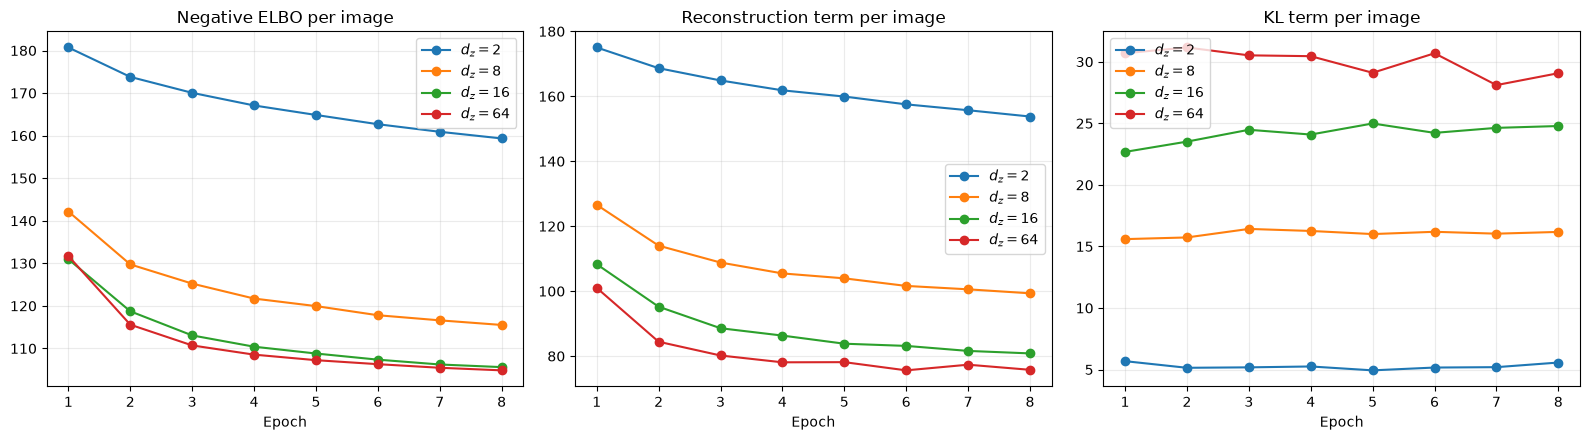

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
metric_specs = [
    ("test_loss", "Negative ELBO per image"),
    ("test_reconstruction", "Reconstruction term per image"),
    ("test_kl", "KL term per image"),
]
for axis, (column, title) in zip(axes, metric_specs):
    for latent_dim, history in histories.items():
        axis.plot(history["epoch"], history[column], marker="o", label=f"$d_z={latent_dim}$")
    axis.set_title(title)
    axis.set_xlabel("Epoch")
    axis.grid(alpha=0.25)
    axis.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_curves.png", dpi=180, bbox_inches="tight")
plt.show()

### Interpretation checkpoint

- Did every model reach a stable region by the final epoch?
- Does increasing $d_z$ consistently improve reconstruction?
- How does the KL term change as more latent dimensions become available?
- Is the lowest negative ELBO automatically the most suitable model for the project scenario?

## 6. Reconstruction comparison

All candidates reconstruct the same test images using posterior means rather than random posterior samples.

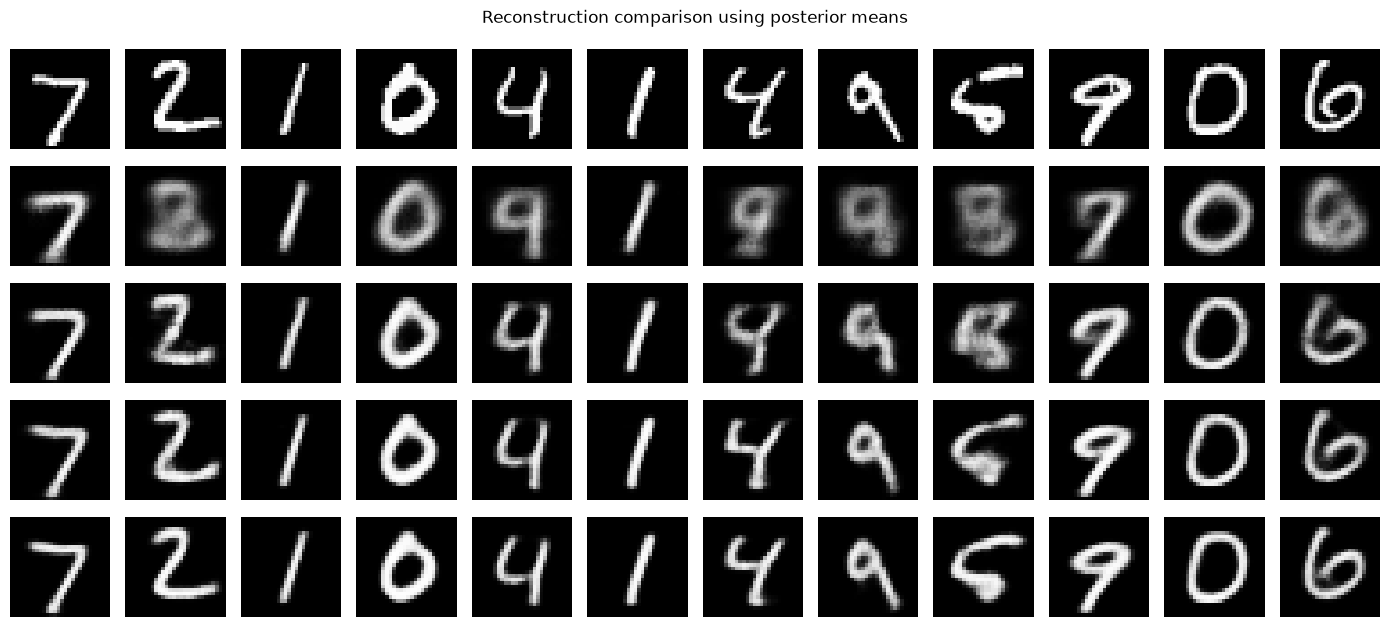

In [10]:
fixed_images, fixed_labels = next(iter(test_loader))
fixed_images = fixed_images[:12].to(device)

reconstruction_rows = [("Original", fixed_images.cpu())]
for latent_dim in LATENT_DIMENSIONS:
    model = models[latent_dim]
    model.eval()
    with torch.no_grad():
        logits, _, _ = model(fixed_images, sample=False)
        reconstructions = torch.sigmoid(logits).cpu()
    reconstruction_rows.append((f"$d_z={latent_dim}$", reconstructions))

fig, axes = plt.subplots(len(reconstruction_rows), 12, figsize=(14, 6.4))
for row_index, (row_label, images) in enumerate(reconstruction_rows):
    for column_index, image in enumerate(images):
        axes[row_index, column_index].imshow(image.squeeze(), cmap="gray", vmin=0, vmax=1)
        axes[row_index, column_index].axis("off")
    axes[row_index, 0].set_ylabel(row_label, rotation=0, labelpad=34, va="center", fontsize=10)
plt.suptitle("Reconstruction comparison using posterior means")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "reconstructions.png", dpi=180, bbox_inches="tight")
plt.show()

### Interpretation checkpoint

- Which visual details improve when $d_z$ increases?
- At what point do additional dimensions produce little visible improvement?
- Identify at least two examples where candidate models differ meaningfully.
- Do the visual results agree with the reconstruction-loss ranking?

## 7. Sampling from the prior

The following images are generated from new latent vectors sampled from the prior:

$$
\mathbf z\sim\mathcal N(0,I).
$$

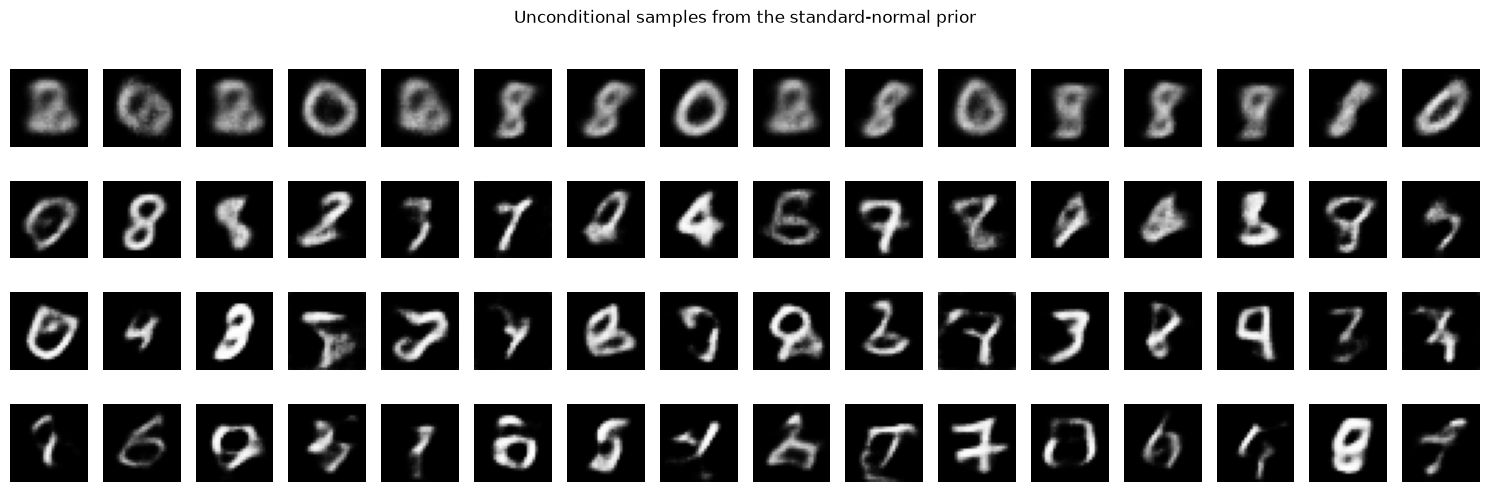

In [11]:
prior_sample_rows = []
for latent_dim in LATENT_DIMENSIONS:
    seed_everything(SEED + 1000)
    model = models[latent_dim]
    model.eval()
    with torch.no_grad():
        z = torch.randn(16, latent_dim, device=device)
        generated = torch.sigmoid(model.decode(z)).cpu()
    prior_sample_rows.append((f"$d_z={latent_dim}$", generated))

fig, axes = plt.subplots(len(prior_sample_rows), 16, figsize=(15, 5.2))
for row_index, (row_label, images) in enumerate(prior_sample_rows):
    for column_index, image in enumerate(images):
        axes[row_index, column_index].imshow(image.squeeze(), cmap="gray", vmin=0, vmax=1)
        axes[row_index, column_index].axis("off")
    axes[row_index, 0].set_ylabel(row_label, rotation=0, labelpad=34, va="center", fontsize=10)
plt.suptitle("Unconditional samples from the standard-normal prior")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "prior_samples.png", dpi=180, bbox_inches="tight")
plt.show()

### Interpretation checkpoint

- Which candidate produces the largest proportion of recognizable digits?
- Which candidate shows the greatest variety?
- Are some candidates sharp but repetitive?
- Does a larger latent space guarantee better prior samples? Explain using the KL regularization term.
- Which defects are not represented by the reconstruction loss?

## 8. Latent interpolation

The same two test images are encoded by every model. The notebook linearly interpolates between their posterior means:

$$
\mathbf z(t)=(1-t)\mathbf z_a+t\mathbf z_b,\qquad t\in[0,1].
$$

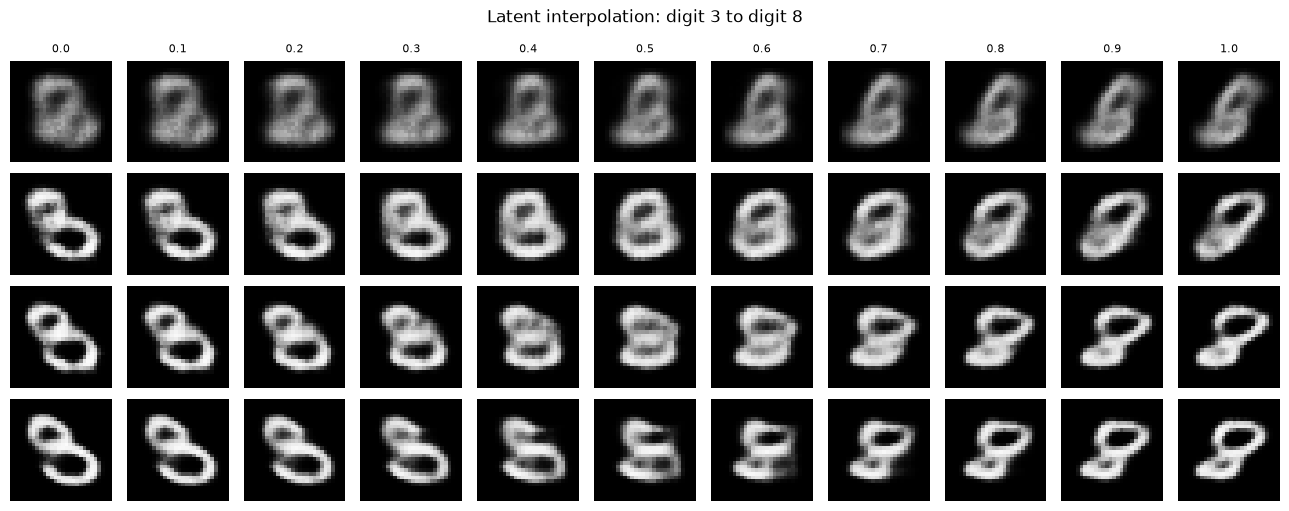

In [12]:
def find_labeled_example(dataset, target_label):
    for image, label in dataset:
        if label == target_label:
            return image
    raise ValueError(f"Label {target_label} was not found.")

start_label, end_label = 3, 8
start_image = find_labeled_example(test_dataset, start_label).unsqueeze(0).to(device)
end_image = find_labeled_example(test_dataset, end_label).unsqueeze(0).to(device)
steps = torch.linspace(0, 1, 11, device=device).unsqueeze(1)
interpolation_rows = []

for latent_dim in LATENT_DIMENSIONS:
    model = models[latent_dim]
    model.eval()
    with torch.no_grad():
        z_start, _ = model.encode(start_image)
        z_end, _ = model.encode(end_image)
        z_path = (1 - steps) * z_start + steps * z_end
        decoded_path = torch.sigmoid(model.decode(z_path)).cpu()
    interpolation_rows.append((f"$d_z={latent_dim}$", decoded_path))

fig, axes = plt.subplots(len(interpolation_rows), 11, figsize=(13, 5.2))
for row_index, (row_label, images) in enumerate(interpolation_rows):
    for column_index, image in enumerate(images):
        axes[row_index, column_index].imshow(image.squeeze(), cmap="gray", vmin=0, vmax=1)
        axes[row_index, column_index].axis("off")
        if row_index == 0:
            axes[row_index, column_index].set_title(f"{column_index / 10:.1f}", fontsize=8)
    axes[row_index, 0].set_ylabel(row_label, rotation=0, labelpad=34, va="center", fontsize=10)
plt.suptitle(f"Latent interpolation: digit {start_label} to digit {end_label}")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "interpolations.png", dpi=180, bbox_inches="tight")
plt.show()

### Interpretation checkpoint

- Which interpolation changes most gradually?
- Do intermediate images remain plausible?
- Does the transition preserve stroke continuity?
- Is a smooth interpolation sufficient to conclude that individual latent dimensions are interpretable?
- Would the conclusion change if a different pair of digits were used?

## 9. Organization of posterior means

For $d_z=2$, posterior means can be plotted directly. Higher-dimensional posterior means are projected to two principal components for visualization. A PCA projection preserves only part of the original information, so visual overlap in two dimensions does not prove overlap in the full latent space.

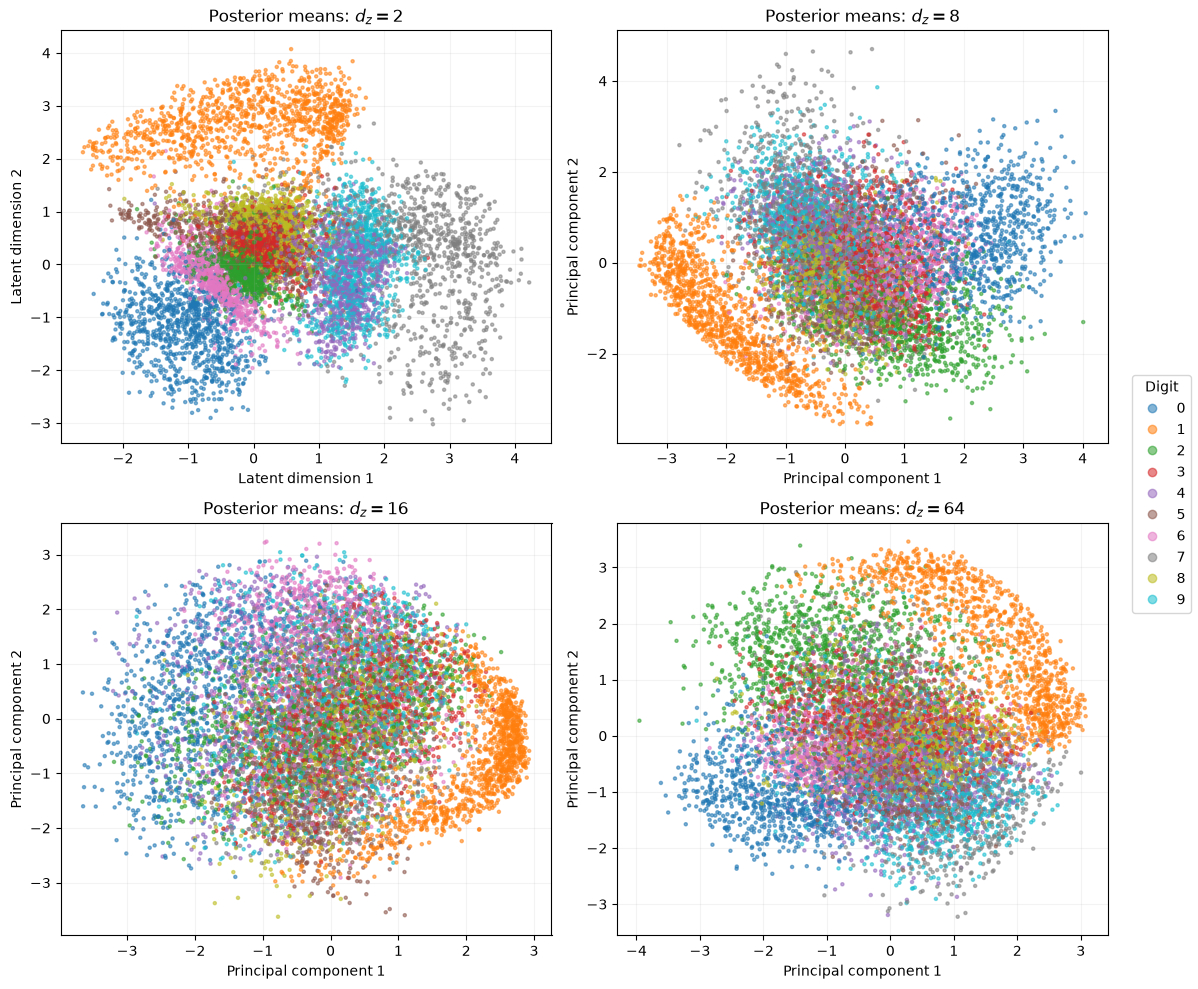

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for axis, latent_dim in zip(axes.flat, LATENT_DIMENSIONS):
    stats = latent_statistics[latent_dim]
    mu = stats["mu"].numpy()
    labels = stats["labels"].numpy()
    if latent_dim == 2:
        coordinates = mu
        axis_labels = ("Latent dimension 1", "Latent dimension 2")
    else:
        coordinates = PCA(n_components=2, random_state=SEED).fit_transform(mu)
        axis_labels = ("Principal component 1", "Principal component 2")

    scatter = axis.scatter(
        coordinates[:, 0], coordinates[:, 1], c=labels, cmap="tab10",
        s=5, alpha=0.55, rasterized=True,
    )
    axis.set_title(f"Posterior means: $d_z={latent_dim}$")
    axis.set_xlabel(axis_labels[0])
    axis.set_ylabel(axis_labels[1])
    axis.grid(alpha=0.15)

handles, _ = scatter.legend_elements(num=10)
fig.legend(handles, [str(number) for number in range(10)], title="Digit", loc="center right")
plt.tight_layout(rect=(0, 0, 0.94, 1))
plt.savefig(OUTPUT_DIR / "latent_space.png", dpi=180, bbox_inches="tight")
plt.show()

### Interpretation checkpoint

- Which digit classes form visibly distinct regions?
- Which classes overlap, and is that visually reasonable?
- Does a more separated two-dimensional projection prove that the corresponding full latent space is superior?
- How does the directly observed $d_z=2$ space differ from the PCA projections?

## 10. Active latent dimensions

A model can be given many latent dimensions without using all of them. The next plot shows the average KL contribution of each dimension. The dashed line is the activity threshold.

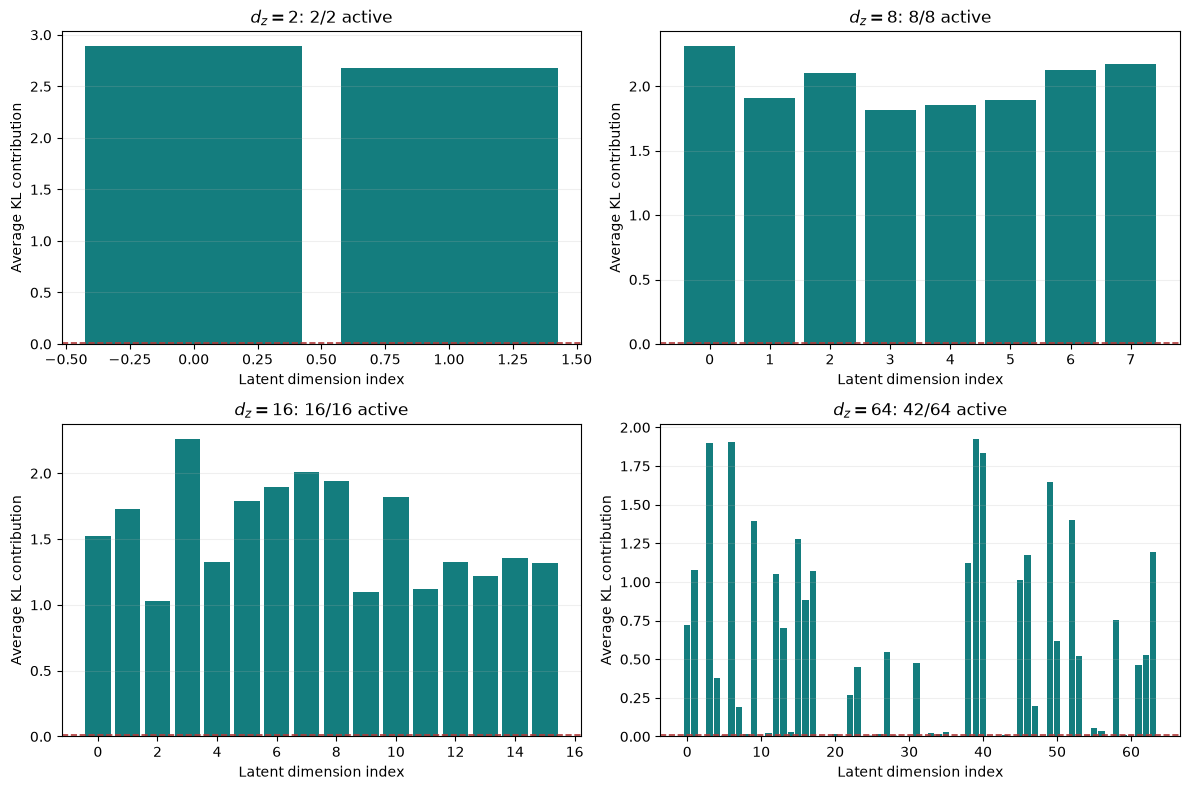

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for axis, latent_dim in zip(axes.flat, LATENT_DIMENSIONS):
    values = latent_statistics[latent_dim]["mean_kl_per_dimension"].numpy()
    colors = np.where(values > ACTIVE_KL_THRESHOLD, "#147D7E", "#B8C3CC")
    axis.bar(np.arange(latent_dim), values, color=colors, width=0.85)
    axis.axhline(ACTIVE_KL_THRESHOLD, color="#B33A3A", linestyle="--", linewidth=1.2)
    active = latent_statistics[latent_dim]["active_dimensions"]
    axis.set_title(f"$d_z={latent_dim}$: {active}/{latent_dim} active")
    axis.set_xlabel("Latent dimension index")
    axis.set_ylabel("Average KL contribution")
    axis.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "active_dimensions.png", dpi=180, bbox_inches="tight")
plt.show()

### Interpretation checkpoint

- Does every candidate use all available dimensions?
- Which candidate has the highest active fraction?
- If the 64-dimensional model uses only a small subset, what does that imply about its effective latent capacity?
- Should inactive dimensions automatically be considered a failure?
- How do active dimensions, total KL, and reconstruction quality relate?

## 11. Final comparison

Use the quantitative table and all qualitative figures together. No single metric measures reconstruction, sampling quality, interpolation, latent efficiency, and computational cost at the same time.

In [15]:
display_columns = [
    "Latent dim", "Parameters", "Test negative ELBO",
    "Test reconstruction", "Test KL",
    "Active dimensions", "Active fraction", "Training seconds",
]
summary[display_columns].style.format({
    "Parameters": "{:,.0f}",
    "Test negative ELBO": "{:.3f}",
    "Test reconstruction": "{:.3f}",
    "Test KL": "{:.3f}",
    "Active fraction": "{:.2%}",
    "Training seconds": "{:.1f}",
})

,Latent dim,Parameters,Test negative ELBO,Test reconstruction,Test KL,Active dimensions,Active fraction,Training seconds
0,2,"88,645",159.342,153.772,5.570,2,100.00%,284.9
1,8,"145,105",115.518,99.339,16.178,8,100.00%,283.9
2,16,"220,385",105.613,80.834,24.779,16,100.00%,399.1
3,64,"672,065",104.853,75.783,29.070,42,65.62%,824.9


## Required conclusion

Complete the accompanying report and recommend one latent dimension for the project scenario. Your conclusion must:

1. state the selected latent dimension;
2. use quantitative evidence from at least three reported quantities;
3. use qualitative evidence from reconstructions, prior samples, and interpolations;
4. discuss latent activity and model compactness;
5. identify at least one weakness of the selected model; and
6. explain one situation in which a different latent dimension would be preferable.

## Output files

After a complete run, the folder `outputs/latent_dimension_experiment/` contains:

- `results.csv` and `summary_table.tex`;
- per-model training histories;
- trained model checkpoints;
- `training_curves.png`;
- `reconstructions.png`;
- `prior_samples.png`;
- `interpolations.png`;
- `latent_space.png`;
- `active_dimensions.png`; and
- `configuration.json`.